In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [16]:
df = pd.read_csv("../data/processed/ratnapark/ratnapark_pm1_pm25_pm10_daily.csv")

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date").reset_index(drop=True)

print("Shape:", df.shape)

display(df.head())

Shape: (1887, 4)


,date,pm1,pm2_5,pm10
0,2016-08-25,144.026083,187.599837,269.346300
1,2016-08-27,121.881565,159.537520,230.975440
2,2016-08-28,98.196718,124.696523,171.362190
3,2016-08-29,54.083770,63.915300,78.042140
4,2016-09-07,127.947061,168.501950,245.585955


In [17]:
print(df.columns.tolist())

['date', 'pm1', 'pm2_5', 'pm10']


In [18]:
print(df.isna().sum())

date     0
pm1      0
pm2_5    0
pm10     0
dtype: int64


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1887 entries, 0 to 1886
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1887 non-null   datetime64[us]
 1   pm1     1887 non-null   float64       
 2   pm2_5   1887 non-null   float64       
 3   pm10    1887 non-null   float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 59.1 KB


In [20]:
full_dates = pd.date_range(
    start=df["date"].min(),
    end=df["date"].max(),
    freq="D"
)

df_daily = (
    df.set_index("date")
      .reindex(full_dates)
      .rename_axis("date")
      .reset_index()
)

In [21]:
print("Original rows:", len(df))
print("Calendar rows:", len(df_daily))

Original rows: 1887
Calendar rows: 3416


In [22]:
display(df_daily[(df_daily["date"] >= "2016-09-25") &(df_daily["date"] <= "2016-09-29")])

,date,pm1,pm2_5,pm10
31,2016-09-25,84.983893,107.614070,146.479725
32,2016-09-26,53.756037,66.504697,89.382590
33,2016-09-27,NaN,NaN,NaN
34,2016-09-28,75.782110,92.105213,114.999075
35,2016-09-29,90.478135,110.280357,141.709305


In [23]:
df_daily["target_pm2_5"] = df_daily["pm2_5"].shift(-1)

In [24]:
pollutants = ["pm1", "pm2_5", "pm10"]

for pollutant in pollutants:
    for lag in range(1, 16):
        df_daily[f"{pollutant}_lag_{lag}"] = (
            df_daily[pollutant].shift(lag)
        )

In [25]:
for pollutant in pollutants:
    for window in [3, 7, 15]:
        df_daily[f"{pollutant}_rolling_mean_{window}"] = (
            df_daily[pollutant]
            .shift(1)
            .rolling(window)
            .mean()
        )

In [28]:
print("Total columns:", len(df_daily.columns))

display(df_daily.head())

Total columns: 59


,date,pm1,pm2_5,pm10,target_pm2_5,pm1_lag_1,pm1_lag_2,pm1_lag_3,pm1_lag_4,pm1_lag_5,...,pm10_lag_15,pm1_rolling_mean_3,pm1_rolling_mean_7,pm1_rolling_mean_15,pm2_5_rolling_mean_3,pm2_5_rolling_mean_7,pm2_5_rolling_mean_15,pm10_rolling_mean_3,pm10_rolling_mean_7,pm10_rolling_mean_15
0,2016-08-25,144.026083,187.599837,269.34630,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-08-26,NaN,NaN,NaN,159.537520,144.026083,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-08-27,121.881565,159.537520,230.97544,124.696523,NaN,144.026083,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-08-28,98.196718,124.696523,171.36219,63.915300,121.881565,NaN,144.026083,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-08-29,54.083770,63.915300,78.04214,NaN,98.196718,121.881565,NaN,144.026083,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
print(df_daily.columns.tolist())

['date', 'pm1', 'pm2_5', 'pm10', 'target_pm2_5', 'pm1_lag_1', 'pm1_lag_2', 'pm1_lag_3', 'pm1_lag_4', 'pm1_lag_5', 'pm1_lag_6', 'pm1_lag_7', 'pm1_lag_8', 'pm1_lag_9', 'pm1_lag_10', 'pm1_lag_11', 'pm1_lag_12', 'pm1_lag_13', 'pm1_lag_14', 'pm1_lag_15', 'pm2_5_lag_1', 'pm2_5_lag_2', 'pm2_5_lag_3', 'pm2_5_lag_4', 'pm2_5_lag_5', 'pm2_5_lag_6', 'pm2_5_lag_7', 'pm2_5_lag_8', 'pm2_5_lag_9', 'pm2_5_lag_10', 'pm2_5_lag_11', 'pm2_5_lag_12', 'pm2_5_lag_13', 'pm2_5_lag_14', 'pm2_5_lag_15', 'pm10_lag_1', 'pm10_lag_2', 'pm10_lag_3', 'pm10_lag_4', 'pm10_lag_5', 'pm10_lag_6', 'pm10_lag_7', 'pm10_lag_8', 'pm10_lag_9', 'pm10_lag_10', 'pm10_lag_11', 'pm10_lag_12', 'pm10_lag_13', 'pm10_lag_14', 'pm10_lag_15', 'pm1_rolling_mean_3', 'pm1_rolling_mean_7', 'pm1_rolling_mean_15', 'pm2_5_rolling_mean_3', 'pm2_5_rolling_mean_7', 'pm2_5_rolling_mean_15', 'pm10_rolling_mean_3', 'pm10_rolling_mean_7', 'pm10_rolling_mean_15']


In [30]:
df_model = df_daily.dropna().copy()

print("Calendar rows:", len(df_daily))
print("Usable modeling rows:", len(df_model))

Calendar rows: 3416
Usable modeling rows: 1409


In [31]:
print(df_model.isna().sum().sum())

0


In [32]:
display(df_model[[
            "date",
            "pm2_5",
            "pm2_5_lag_1",
            "pm2_5_lag_15",
            "target_pm2_5"
        ]
    ].head(10)
)

,date,pm2_5,pm2_5_lag_1,pm2_5_lag_15,target_pm2_5
49,2016-10-13,107.120657,70.023423,92.105213,110.907640
50,2016-10-14,110.907640,107.120657,110.280357,120.285923
51,2016-10-15,120.285923,110.907640,63.211730,129.241130
52,2016-10-16,129.241130,120.285923,66.716017,124.030080
53,2016-10-17,124.030080,129.241130,118.627510,116.180793
54,2016-10-18,116.180793,124.030080,123.281350,148.270110
55,2016-10-19,148.270110,116.180793,132.119323,143.660533
56,2016-10-20,143.660533,148.270110,115.576427,132.996460
57,2016-10-21,132.996460,143.660533,95.507687,159.309977
58,2016-10-22,159.309977,132.996460,106.309650,152.326270


### Because we predicted pm1 and it is not actual ones , so what I am thinking is building two models . 
1. ## Model A :without PM1 
2. ## Model B :with pm1

In [33]:
target = "target_pm2_5"

## Model A 

In [34]:
features_without_pm1 = [
    col for col in df_model.columns
    if (
        col.startswith("pm2_5_lag_")
        or col.startswith("pm10_lag_")
        or col.startswith("pm2_5_rolling_mean_")
        or col.startswith("pm10_rolling_mean_")
    )
]

In [36]:
print("Features without PM1:", len(features_without_pm1))
print(features_without_pm1)

Features without PM1: 36
['pm2_5_lag_1', 'pm2_5_lag_2', 'pm2_5_lag_3', 'pm2_5_lag_4', 'pm2_5_lag_5', 'pm2_5_lag_6', 'pm2_5_lag_7', 'pm2_5_lag_8', 'pm2_5_lag_9', 'pm2_5_lag_10', 'pm2_5_lag_11', 'pm2_5_lag_12', 'pm2_5_lag_13', 'pm2_5_lag_14', 'pm2_5_lag_15', 'pm10_lag_1', 'pm10_lag_2', 'pm10_lag_3', 'pm10_lag_4', 'pm10_lag_5', 'pm10_lag_6', 'pm10_lag_7', 'pm10_lag_8', 'pm10_lag_9', 'pm10_lag_10', 'pm10_lag_11', 'pm10_lag_12', 'pm10_lag_13', 'pm10_lag_14', 'pm10_lag_15', 'pm2_5_rolling_mean_3', 'pm2_5_rolling_mean_7', 'pm2_5_rolling_mean_15', 'pm10_rolling_mean_3', 'pm10_rolling_mean_7', 'pm10_rolling_mean_15']


In [39]:
split_index = int(len(df_model) * 0.8)

train = df_model.iloc[:split_index].copy()
test = df_model.iloc[split_index:].copy()

print("Training samples:", len(train))
print("Testing samples:", len(test))

print("\nTraining period:")
print(train["date"].min(), "→", train["date"].max())

print("\nTesting period:")
print(test["date"].min(), "→", test["date"].max())

Training samples: 1127
Testing samples: 282

Training period:
2016-10-13 00:00:00 → 2024-12-22 00:00:00

Testing period:
2024-12-23 00:00:00 → 2025-12-30 00:00:00


In [42]:
X_train_without = train[features_without_pm1]
X_test_without = test[features_without_pm1]

y_train = train[target]
y_test = test[target]

In [43]:
model_without_pm1 = LinearRegression()
model_without_pm1.fit(X_train_without,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](36,)","[ 0.69,-0.48,-0.02,..., 0.07, 0. ,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](36,)","['pm2_5_lag_1','pm2_5_lag_2','pm2_5_lag_3',...,'pm10_rolling_mean_3', 'pm10_rolling_mean_7','pm10_rolling_mean_15']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.364
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,36
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(30)


In [44]:
pred_without_pm1 = model_without_pm1.predict(X_test_without)

In [45]:
mae_without = mean_absolute_error(y_test, pred_without_pm1)

rmse_without = np.sqrt(
    mean_squared_error(y_test, pred_without_pm1)
)

r2_without = r2_score(y_test, pred_without_pm1)

print("PM2.5 Forecasting — WITHOUT PM1")
print("MAE :", round(mae_without, 3))
print("RMSE:", round(rmse_without, 3))
print("R²  :", round(r2_without, 3))

PM2.5 Forecasting — WITHOUT PM1
MAE : 10.088
RMSE: 13.757
R²  : 0.768


## Model B

In [37]:
features_with_pm1 = [
    col for col in df_model.columns
    if (
        col.startswith("pm1_lag_")
        or col.startswith("pm2_5_lag_")
        or col.startswith("pm10_lag_")
        or col.startswith("pm1_rolling_mean_")
        or col.startswith("pm2_5_rolling_mean_")
        or col.startswith("pm10_rolling_mean_")
    )
]

In [38]:
print("Features with PM1:", len(features_with_pm1))
print(features_with_pm1)

Features with PM1: 54
['pm1_lag_1', 'pm1_lag_2', 'pm1_lag_3', 'pm1_lag_4', 'pm1_lag_5', 'pm1_lag_6', 'pm1_lag_7', 'pm1_lag_8', 'pm1_lag_9', 'pm1_lag_10', 'pm1_lag_11', 'pm1_lag_12', 'pm1_lag_13', 'pm1_lag_14', 'pm1_lag_15', 'pm2_5_lag_1', 'pm2_5_lag_2', 'pm2_5_lag_3', 'pm2_5_lag_4', 'pm2_5_lag_5', 'pm2_5_lag_6', 'pm2_5_lag_7', 'pm2_5_lag_8', 'pm2_5_lag_9', 'pm2_5_lag_10', 'pm2_5_lag_11', 'pm2_5_lag_12', 'pm2_5_lag_13', 'pm2_5_lag_14', 'pm2_5_lag_15', 'pm10_lag_1', 'pm10_lag_2', 'pm10_lag_3', 'pm10_lag_4', 'pm10_lag_5', 'pm10_lag_6', 'pm10_lag_7', 'pm10_lag_8', 'pm10_lag_9', 'pm10_lag_10', 'pm10_lag_11', 'pm10_lag_12', 'pm10_lag_13', 'pm10_lag_14', 'pm10_lag_15', 'pm1_rolling_mean_3', 'pm1_rolling_mean_7', 'pm1_rolling_mean_15', 'pm2_5_rolling_mean_3', 'pm2_5_rolling_mean_7', 'pm2_5_rolling_mean_15', 'pm10_rolling_mean_3', 'pm10_rolling_mean_7', 'pm10_rolling_mean_15']


In [41]:
split_index = int(len(df_model) * 0.8)

train = df_model.iloc[:split_index].copy()
test = df_model.iloc[split_index:].copy()

print("Training samples:", len(train))
print("Testing samples:", len(test))

print("\nTraining period:")
print(train["date"].min(), "→", train["date"].max())

print("\nTesting period:")
print(test["date"].min(), "→", test["date"].max())

Training samples: 1127
Testing samples: 282

Training period:
2016-10-13 00:00:00 → 2024-12-22 00:00:00

Testing period:
2024-12-23 00:00:00 → 2025-12-30 00:00:00


In [46]:
X_train_with = train[features_with_pm1]
X_test_with = test[features_with_pm1]

In [47]:
model_with_pm1 = LinearRegression()

model_with_pm1.fit(X_train_with,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](54,)","[-1.11, 2.62,-0.54,..., 0.24,-0. ,-0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](54,)","['pm1_lag_1','pm1_lag_2','pm1_lag_3',...,'pm10_rolling_mean_3', 'pm10_rolling_mean_7','pm10_rolling_mean_15']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.976
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,54
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(45)


In [48]:
pred_with_pm1 = model_with_pm1.predict(X_test_with)

In [49]:
mae_with = mean_absolute_error(y_test, pred_with_pm1)

rmse_with = np.sqrt(
    mean_squared_error(y_test, pred_with_pm1)
)

r2_with = r2_score(y_test, pred_with_pm1)

print("PM2.5 Forecasting — WITH PM1")
print("MAE :", round(mae_with, 3))
print("RMSE:", round(rmse_with, 3))
print("R²  :", round(r2_with, 3))

PM2.5 Forecasting — WITH PM1
MAE : 10.141
RMSE: 14.005
R²  : 0.76


## Comparision


In [ ]:
comparison = pd.DataFrame({"Model": ["Without PM1","With PM1"],
    "MAE": [mae_without,mae_with],
    "RMSE": [rmse_without,rmse_with],
    "R2": [r2_without,r2_with]
})

display(comparison)

,Model,MAE,RMSE,R2
0,Without PM1,10.087855,13.756986,0.768130
1,With PM1,10.140645,14.005242,0.759686


## Visualization


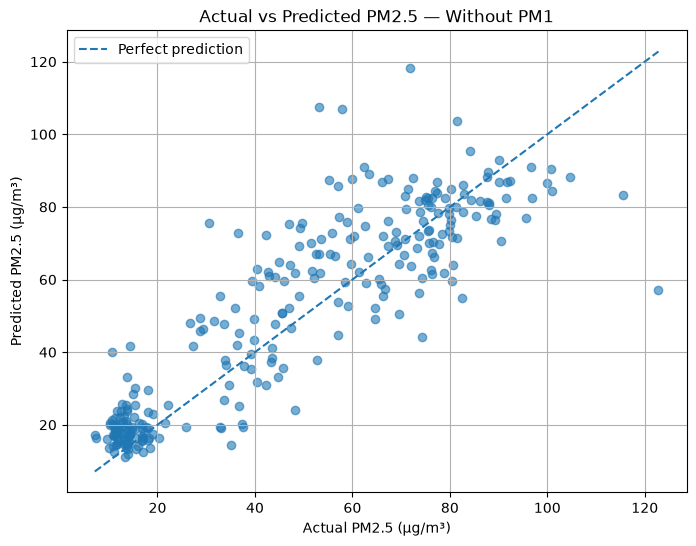

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, pred_without_pm1, alpha=0.6)

min_val = min(y_test.min(), pred_without_pm1.min())
max_val = max(y_test.max(), pred_without_pm1.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Actual vs Predicted PM2.5 — Without PM1")
plt.legend()
plt.grid(True)
plt.show()

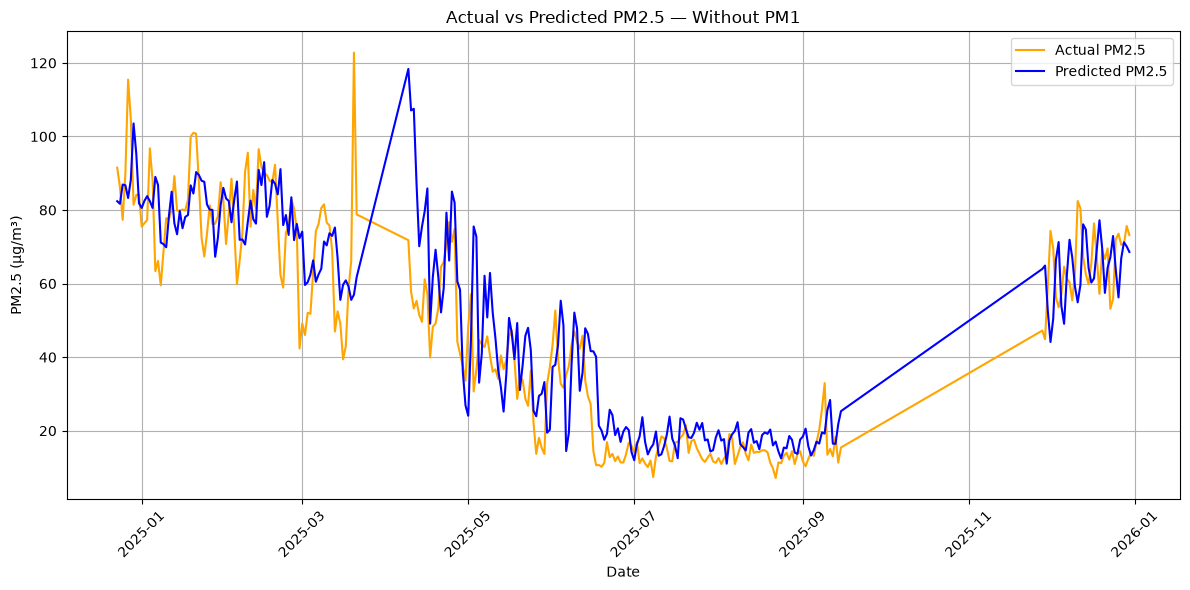

In [53]:
plt.figure(figsize=(12, 6))

plt.plot(
    test["date"],
    y_test,
    label="Actual PM2.5",
    color="orange"
)

plt.plot(
    test["date"],
    pred_without_pm1,
    label="Predicted PM2.5",
    color="blue"
)

plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³)")
plt.title("Actual vs Predicted PM2.5 — Without PM1")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

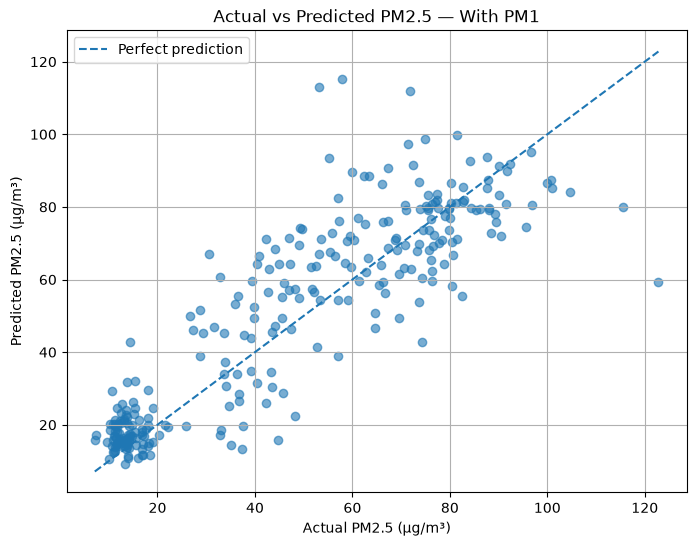

In [54]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, pred_with_pm1, alpha=0.6)

min_val = min(y_test.min(), pred_with_pm1.min())
max_val = max(y_test.max(), pred_with_pm1.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Actual vs Predicted PM2.5 — With PM1")
plt.legend()
plt.grid(True)
plt.show()

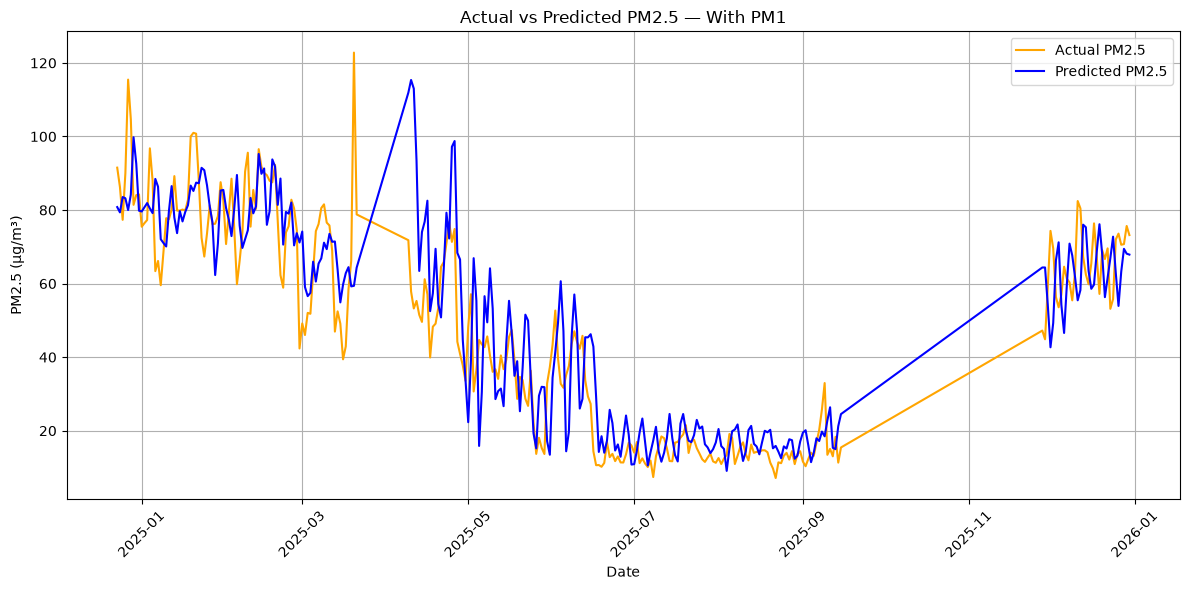

In [55]:
plt.figure(figsize=(12, 6))

plt.plot(
    test["date"],
    y_test,
    label="Actual PM2.5",
    color="orange"
)

plt.plot(
    test["date"],
    pred_with_pm1,
    label="Predicted PM2.5",
    color="blue"
)

plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³)")
plt.title("Actual vs Predicted PM2.5 — With PM1")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()